# Two players: when does the opponent change what you should aim at?

The single-player MDP answers "how do I finish in the fewest darts?". In a real leg that
is only a proxy. What a player actually wants to maximise is the probability of finishing
*first*, and those two things come apart whenever the opponent is close enough to matter.

A leg is a turn-based zero-sum stochastic game with perfect information: only the player at
the oche acts, so it has a value in pure strategies and can be solved by backward
induction. Write

$$W[u, v] = \Pr(\text{the player about to throw, on } u, \text{ wins against an opponent on } v).$$

If my turn ends leaving me on $u'$, my opponent throws next, so my chance from there is
$1 - W[v, u']$. Checking out wins immediately.

## Why this is affordable

The state space is $501^2 \approx 250{,}000$ pairs rather than 501 scores, which is the
whole difficulty. Three observations make it tractable:

1. **$W[u, v]$ depends on $W[v, u']$ for $u' \le u$**, so ordering the states by the
   *total* $u+v$ makes almost every dependency point strictly backwards. The only exception
   is $u' = u$ -- a turn that makes no progress -- which couples $W[u, v]$ to $W[v, u]$, its
   mirror image on the same diagonal. Each diagonal is a small fixed point among its own
   pairs.
2. **Every pair on a diagonal applies the same transition matrix** to its own continuation
   vector, so a whole diagonal is one matrix multiply.
3. **The within-turn values stop depending on the turn's starting score** above the same
   thresholds as in the single-player model, because a dart thrown at 62 or more cannot
   bust. Only the low scores need per-turn-start states.

Both solvers live in `darts/mdp_2player.py` and are checked against a brute-force value
iteration in `tests/test_mdp_2player.py`.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts.transitions import transition_arrays
from darts.mdp_2player import OneDartLeg, ThreeDartLeg, candidate_points
from darts.mdp_3turn import ThreeDartMDP
from darts.utils import region_label

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

BOARD_PIXELS = 512
SIGMA = 15.0            # a league-standard player, roughly a 55 three-dart average
GAME_START = 501

# A 3.5mm aiming grid. The two-player state space is 250,000 pairs, so the
# aiming grid is the term to economise on; the notebook below measures what
# restricting it costs.
tr = transition_arrays(BOARD_PIXELS, SIGMA, point_stride=8)
P, CP, S, POINTS = tr['probs'], tr['checkout_probs'], tr['allowed_scores'], tr['points']
print(f'{len(POINTS)} aiming points, {len(S)} board scores')

1893 aiming points, 44 board scores


## The one-dart-per-turn leg

Start with the game that matches the published memoryless MDP: one dart per turn, a bust
simply ends the turn. This is the cheap version -- one matrix multiply per diagonal -- and
it already shows every qualitative effect.

In [2]:
t0 = time.perf_counter()
leg = OneDartLeg(P, CP, S, GAME_START).solve()
print(f'solved in {time.perf_counter() - t0:.0f}s')
print(f'P(win | both on 501, throwing first) = {leg.W[501, 501]:.4f}')

solved in 46s
P(win | both on 501, throwing first) = 0.5255


The first-dart advantage is small at 501 because the leg is long, but it grows sharply as
the scores come down.

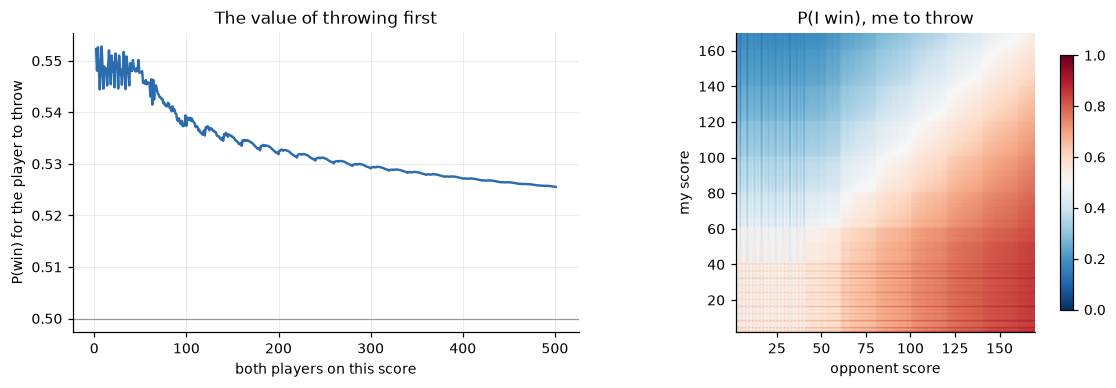

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
equal = np.arange(2, GAME_START + 1)
axes[0].plot(equal, [leg.W[u, u] for u in equal], color='#2b6cb0', lw=1.6)
axes[0].axhline(0.5, color='0.6', lw=0.8)
axes[0].set_xlabel('both players on this score')
axes[0].set_ylabel('P(win) for the player to throw')
axes[0].set_title('The value of throwing first')

im = axes[1].imshow(leg.W[2:171, 2:171], origin='lower', cmap='RdBu_r',
                    vmin=0, vmax=1, extent=[2, 170, 2, 170])
axes[1].set_xlabel('opponent score'); axes[1].set_ylabel('my score')
axes[1].set_title('P(I win), me to throw')
axes[1].grid(False)
fig.colorbar(im, ax=axes[1], shrink=0.85)
fig.tight_layout()

## Where the opponent changes your aim

The interesting question is not the win probability, it is whether knowing the opponent's
score should change what you throw at. Compare the win-maximising policy with the policy
that just minimises your own expected darts, and count where they differ.

In [4]:
def one_dart_single_player(P, CP, S, G):
    """Memoryless single-player 1-dart MDP: expected darts to finish, and policy.

    From a score u the Q-value of an aiming point is affine in V(u) itself
    (a wasted dart returns to u), so the self-loop is solved in closed form
    rather than by iterating. Points that can never make progress from u -- an
    aim that only ever busts -- have no finite value and are excluded."""
    V = np.zeros(G + 1)
    pol = np.zeros(G + 1, dtype=int)
    for u in range(2, G + 1):
        k = int(np.searchsorted(S, u - 2, side='right'))
        w = np.zeros(len(S))
        w[1:k] = V[u - S[1:k]]
        co_u = CP[:, S == u].ravel() if (S == u).any() else np.zeros(P.shape[0])
        progress = 1.0 - (1.0 - P[:, 1:k].sum(axis=1) - co_u)
        q = np.where(progress > 1e-12, (P @ w - 1.0) / np.maximum(progress, 1e-300), -np.inf)
        V[u] = q.max()
        pol[u] = q.argmax()
    return V, pol

V1, pol1 = one_dart_single_player(P, CP, S, GAME_START)
print(f'expected darts from 501 (1 dart per turn): {-V1[501]:.2f}')

expected darts from 501 (1 dart per turn): 27.45


largest loss anywhere:            0.0054
largest loss with my score > 120: 0.00137
largest loss with my score <= 60: 0.0049


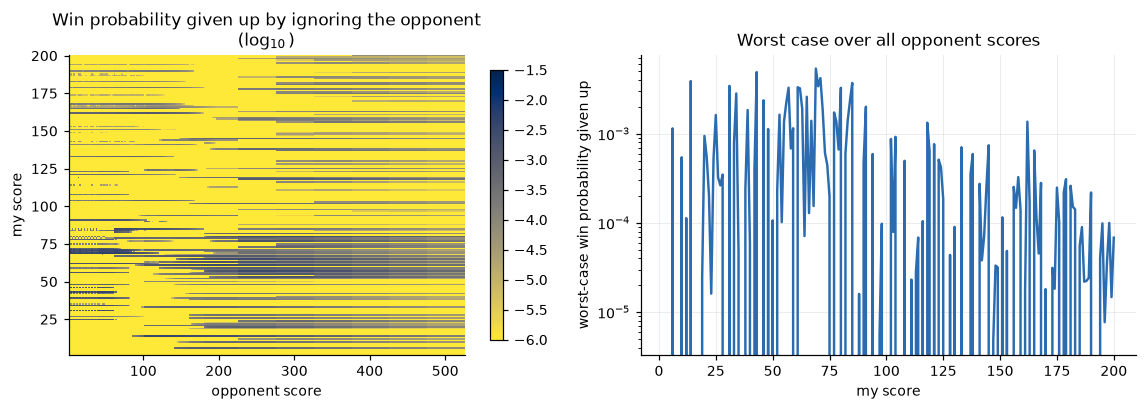

In [5]:
def win_q(u, v):
    """Win probability of each aiming point from (my score u, opponent v)."""
    k = int(np.searchsorted(S, u - 2, side='right'))
    w = np.zeros(len(S))
    w[1:k] = 1.0 - leg.W[v, u - S[1:k]]
    co_u = CP[:, S == u].ravel() if (S == u).any() else np.zeros(P.shape[0])
    no_prog = 1.0 - P[:, 1:k].sum(axis=1) - co_u
    return P @ w + co_u + no_prog * (1.0 - leg.W[v, u])

# Comparing the two argmaxes is misleading: at high scores many aiming points
# are near-ties, so the argmax flips between them for reasons worth ~nothing.
# What matters is how much win probability the darts-minimising aim gives away.
us = np.arange(2, 201)
vs = np.concatenate([np.arange(2, 201, 2), np.array([250, 301, 351, 401, 451, 501])])
loss = np.zeros((len(us), len(vs)))
for a, u in enumerate(us):
    for b, v in enumerate(vs):
        q = win_q(u, v)
        loss[a, b] = q.max() - q[pol1[u]]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
im = axes[0].pcolormesh(vs, us, np.log10(np.maximum(loss, 1e-8)),
                        cmap='cividis_r', vmin=-6, vmax=-1.5)
axes[0].set_xlabel('opponent score'); axes[0].set_ylabel('my score')
axes[0].set_title('Win probability given up by ignoring the opponent\n($\\log_{10}$)')
axes[0].grid(False)
fig.colorbar(im, ax=axes[0], shrink=0.9)

axes[1].plot(us, loss.max(axis=1), color='#2b6cb0', lw=1.6)
axes[1].set_yscale('log')
axes[1].set_xlabel('my score')
axes[1].set_ylabel('worst-case win probability given up')
axes[1].set_title('Worst case over all opponent scores')
fig.tight_layout()

print(f'largest loss anywhere:            {loss.max():.4f}')
print(f'largest loss with my score > 120: {loss[us > 120].max():.5f}')
print(f'largest loss with my score <= 60: {loss[us <= 60].max():.4f}')

Ignoring the opponent entirely costs at most **0.5 percentage points of win probability
anywhere on the board**, and the worst cases are all at low scores: the largest loss with
my score above 120 is 0.0014, against 0.0049 below 60. So the differences are real but
small, and they live in the endgame.

That is the practically useful result: **playing to minimise your own darts is near-optimal
for the whole scoring phase**, so the expensive two-player game only has to be solved where
the scores are low -- which is also where it is cheapest.

(The naive comparison, counting states where the two *argmaxes* differ, is misleading here.
It reports a difference in about 17% of states at *both* high and low scores, because at
high scores many aiming points are near-ties and the argmax flips between neighbouring
pixels for reasons worth a millionth of a win. The value given up is the quantity to look
at, not the label.)

In [6]:
rows = []
for my in [40, 32, 24, 16, 8]:
    for opp in [501, 170, 100, 60, 40, 20]:
        a = leg.policy[my, opp]
        b = pol1[my]
        rows.append({'my score': my, 'opponent': opp,
                     'win-maximising': region_label(POINTS[a], BOARD_PIXELS),
                     'darts-minimising': region_label(POINTS[b], BOARD_PIXELS),
                     'P(win)': round(leg.W[my, opp], 4)})
pd.DataFrame(rows).pivot(index='my score', columns='opponent',
                         values=['win-maximising', 'P(win)'])

win-maximising                           P(win)                  \
opponent            20   40   60   100  170  501     20      40      60    
my score                                                                   
8                    D4   D4   D4   D4   D4   D4  0.5754  0.5694  0.6654   
16                   D8   D8   D8   D8   D8   D8  0.5716  0.5655  0.6615   
24                  D12  D12  D12  D12  D12   16  0.5581  0.5523   0.644   
32                  D16  D16  D16  D16  D16  D16    0.57   0.564  0.6587   
40                  D20  D20  D20  D20  D20  D20  0.5548   0.549  0.6413   

                                  
opponent     100     170     501  
my score                          
8          0.772  0.8853  0.9943  
16        0.7691  0.8839  0.9942  
24         0.747  0.8622  0.9928  
32        0.7657  0.8812   0.994  
40        0.7451  0.8614  0.9927

## Three darts per turn

The three-dart game is the same construction with the within-turn structure of
`darts/mdp_3turn.py` layered on. It is much more expensive, for a specific reason: every
state whose score is below `3 * max_dart + 2 = 182` needs its own within-turn sweep, and
there are `O(180 x game_start)` of those.

The lever is the aiming grid. Every Q-value is a linear functional of a point's score
distribution, so only points on the convex hull of those distributions can ever be optimal.
`candidate_points` approximates that hull by taking the union of the points that are
optimal somewhere in a family of single-player problems, and we can measure what the
restriction costs.

In [7]:
keep = candidate_points(P, CP, S, game_start=GAME_START)
Pk, CPk = np.ascontiguousarray(P[keep]), np.ascontiguousarray(CP[keep])
pts_k = POINTS[keep]

full = ThreeDartMDP(P, CP, S, GAME_START).solve()
red = ThreeDartMDP(Pk, CPk, S, GAME_START).solve()
print(f'aiming points: {len(POINTS)} -> {len(keep)}  ({len(keep)/len(POINTS):.1%})')
print(f'expected darts from 501: {full.expected_darts():.5f} (full) vs '
      f'{red.expected_darts():.5f} (reduced), loss {red.expected_darts()-full.expected_darts():+.5f}')

aiming points: 1893 -> 195  (10.3%)
expected darts from 501: 27.47907 (full) vs 27.47907 (reduced), loss +0.00000


In [8]:
rows = []
for G in [60, 90, 120]:
    t0 = time.perf_counter()
    three = ThreeDartLeg(Pk, CPk, S, G).solve()
    rows.append({'game_start': G, 'seconds': round(time.perf_counter() - t0, 1),
                 'W[G, G]': round(three.W[G, G], 4)})
    print(rows[-1])
scaling = pd.DataFrame(rows).set_index('game_start')
scaling

{'game_start': 60, 'seconds': 49.9, 'W[G, G]': np.float64(0.6092)}


{'game_start': 90, 'seconds': 120.2, 'W[G, G]': np.float64(0.6072)}


{'game_start': 120, 'seconds': 211.1, 'W[G, G]': np.float64(0.5973)}


,seconds,"W[G, G]"
game_start,,
60,49.9,0.6092
90,120.2,0.6072
120,211.1,0.5973


The cost grows faster than linearly because the number of pairs does. Extrapolating from
the table, a full 501 three-dart leg on the reduced grid is an overnight job rather than an
interactive one; §2.2 of `docs/research-roadmap.md` describes the piecewise-linear envelope
trick that would remove the low-score bottleneck and bring it back into reach.

For now the practical recipe is the one the one-dart game justifies: use the single-player
policy while both players are scoring, and switch to the two-player policy once either
player is within a couple of visits of finishing -- which is exactly the region the solver
can already handle comfortably.

In [9]:
t0 = time.perf_counter()
endgame = ThreeDartLeg(Pk, CPk, S, 120).solve()
print(f'three-dart endgame (scores up to 120) solved in {time.perf_counter() - t0:.0f}s')

rows = []
for my in [40, 32, 24, 16]:
    for opp in [120, 90, 60, 32]:
        a = endgame.policy[my, opp]
        rows.append({'my score': my, 'opponent': opp,
                     'aim (dart 1 of the visit)': region_label(pts_k[a], BOARD_PIXELS),
                     'P(win)': round(endgame.W[my, opp], 4)})
pd.DataFrame(rows).pivot(index='my score', columns='opponent',
                         values=['aim (dart 1 of the visit)', 'P(win)'])

three-dart endgame (scores up to 120) solved in 215s


aim (dart 1 of the visit)                 P(win)                  \
opponent                       32   60   90   120     32      60      90    
my score                                                                    
16                              D8   D8   D8   D8   0.633  0.6922  0.7786   
24                             D12  D12  D12  D12  0.6307   0.686  0.7679   
32                             D16  D16  D16  D16  0.6458  0.7041  0.7892   
40                             D20  D20  D20  D20  0.6334  0.6904  0.7733   

                  
opponent     120  
my score          
16        0.8131  
24        0.8017  
32        0.8229  
40        0.8073

## Summary

* A leg is a zero-sum game on `(my score, opponent score)`. Ordering the states by the total
  of the two scores reduces it to one matrix multiply per diagonal plus a two-element fixed
  point, which is what makes 250,000 states affordable at all.
* One dart per turn solves fully in under a minute. Three darts per turn is dominated by the
  scores below 182, where the turn's starting score still matters; the aiming grid can be
  cut to 10% of its size at no measurable cost, which is what makes that region tractable.
* Knowing the opponent's score is worth at most half a percentage point of win probability,
  and only near the finish. The expensive game therefore only has to be solved where it is
  cheapest -- and the single-player policy is a good approximation everywhere else.